# Obtain and Load Data


---
Problem: Predict "Median House Value" based on the relationship between other independent variables (features).


In [ ]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np


In [ ]:
# dataset loaded by using url
url = 'https://raw.githubusercontent.com/LinkedInLearning/artificial-intelligence-foundations-machine-learning-3067770/main/housing.csv'


# read in the data with read_csv() into a Pandas Dataframe
housing_df = pd.read_csv(url)


In [ ]:
# dataset loaded by import the dataset as a file (csv)
# read in the data with read_csv() into a Pandas Dataframe

housing_df = pd.read_csv('housing.csv')

# use info to show the features in your dataset along with a count and datatype
housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Prepare & Preprocess Data

---

**Understand the missing data**

They could skew the model.

In [ ]:
# Verify which feature has missing values
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# Calculate the percentage(%) of missing data

MValue = housing_df['total_bedrooms'].isnull().sum()/housing_df.shape[0] * 100
print('Missing values percentage =', MValue )

Missing values percentage = 1.002906976744186


In [ ]:
# there are 207 missing values in total_betrooms feature
# This might be incorrect because every home should have at least one bedroom.
# So need to handle these missing values appropriately.

**Ways to handle missing values**
1. Remove missing values (Applicable if it not effect the size of the dataset and # of missing data are very few.)
2. Mean / Median Imputation - Replace missing value with mean or average score of the rest of the data. (Applicable only for numeric values)
3. Mode imputation (Applicable for ctegorical values)
4. Imputate missing data using ML

> Can use KNN algorithm to impute(predit) missing values

*   KNN identifies a sample with missin values
*   Then it identifies the most similar values that are in complete samlples (samples with no missing values) & replace missing values


**Imputate missing data using ML - KNN**

In [ ]:
from sklearn.impute import KNNImputer

# Create a temporary copy of dataset
housing_df_temp = housing_df.copy()

# Retrieve columns with numerical data (Exclude ocean_proximity column)
columns_list = [col for col in housing_df_temp.columns if housing_df_temp[col].dtype != 'object']

# Extract numeric columns from the dataset from temporary dataframe
housing_numeric = housing_df_temp[columns_list]


In [ ]:
# initialize KNNImputer to impute missing data using ML
Knn = KNNImputer(n_neighbors=3)

# fit funtion to train the model
Knn.fit(housing_numeric)

# transform the data using the model
# applies the transformation model to update
array_value = Knn.transform(housing_numeric)

# convert the array values into a dataframe with the appropriate column names
housing_numeric = pd.DataFrame(array_value, columns = columns_list)

#confirm there are no columns with missing values
housing_numeric.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
# overlay the imputed column over the old column with missing values.

# loop through the list of columns and overlay each one
for column_name in columns_list:
  housing_df[column_name] = housing_numeric[column_name]

# confirm columns no longer contain null data
housing_df.isnull().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


# Use visualization to understand the relationship of the target variable with other features (variables).


---

**1.  Histograms**

Text(0, 0.5, 'Frequency - Number of Houses')

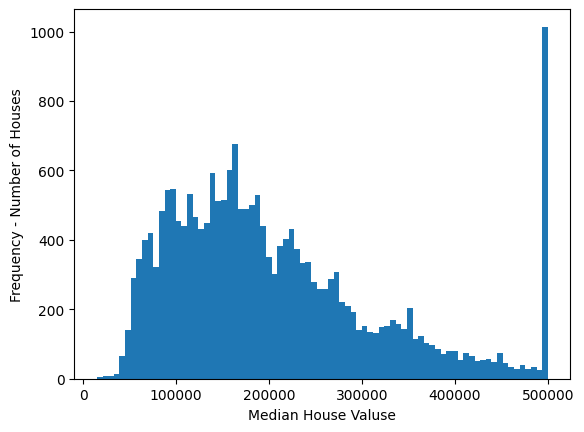

In [ ]:
# Plot the distribution of target variable (Median House Value) using a histrogram.

# bins -> Amount of columns / Number of bars in the histogram

plt.hist(housing_df['median_house_value'], bins=80)
plt.xlabel('Median House Valuse')
plt.ylabel('Frequency - Number of Houses')


```
Output - Text(0, 0.5, 'Frequency - Number of Houses')
```

It means;
*   Text → a text object was created
*   0 → x-position of the label
*   0.5 → y-position of the label
*   'Frequency' → the actual text displayed

---


🔹 Can hide it using;
```
plt.ylabel('Frequency');
```
or
```
plt.show()
```





**More bins → more detailed view**

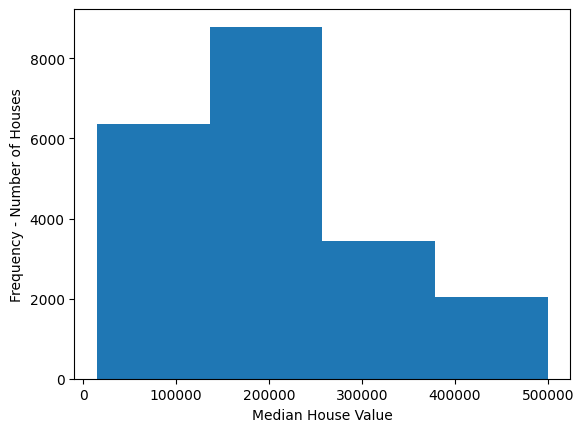

In [ ]:
plt.hist(housing_df['median_house_value'], bins=4)
plt.xlabel('Median House Value')
plt.ylabel('Frequency - Number of Houses');

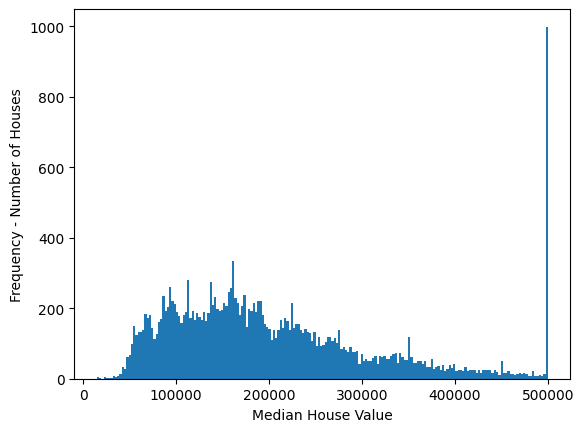

In [ ]:
plt.hist(housing_df['median_house_value'], bins=200)
plt.xlabel('Median House Value')
plt.ylabel('Frequency - Number of Houses')

plt.show()


**Observation**

*   Most of the houses around range 100,000 - 200,000
*   We can see the valuse of 'Median House Value' distributed normally with fewer outliers.



**Histrograms for all other features to understand the data distributions.**

🔹 Since 'ocean_proximity' is non-numeric, a histrogram is not needed.

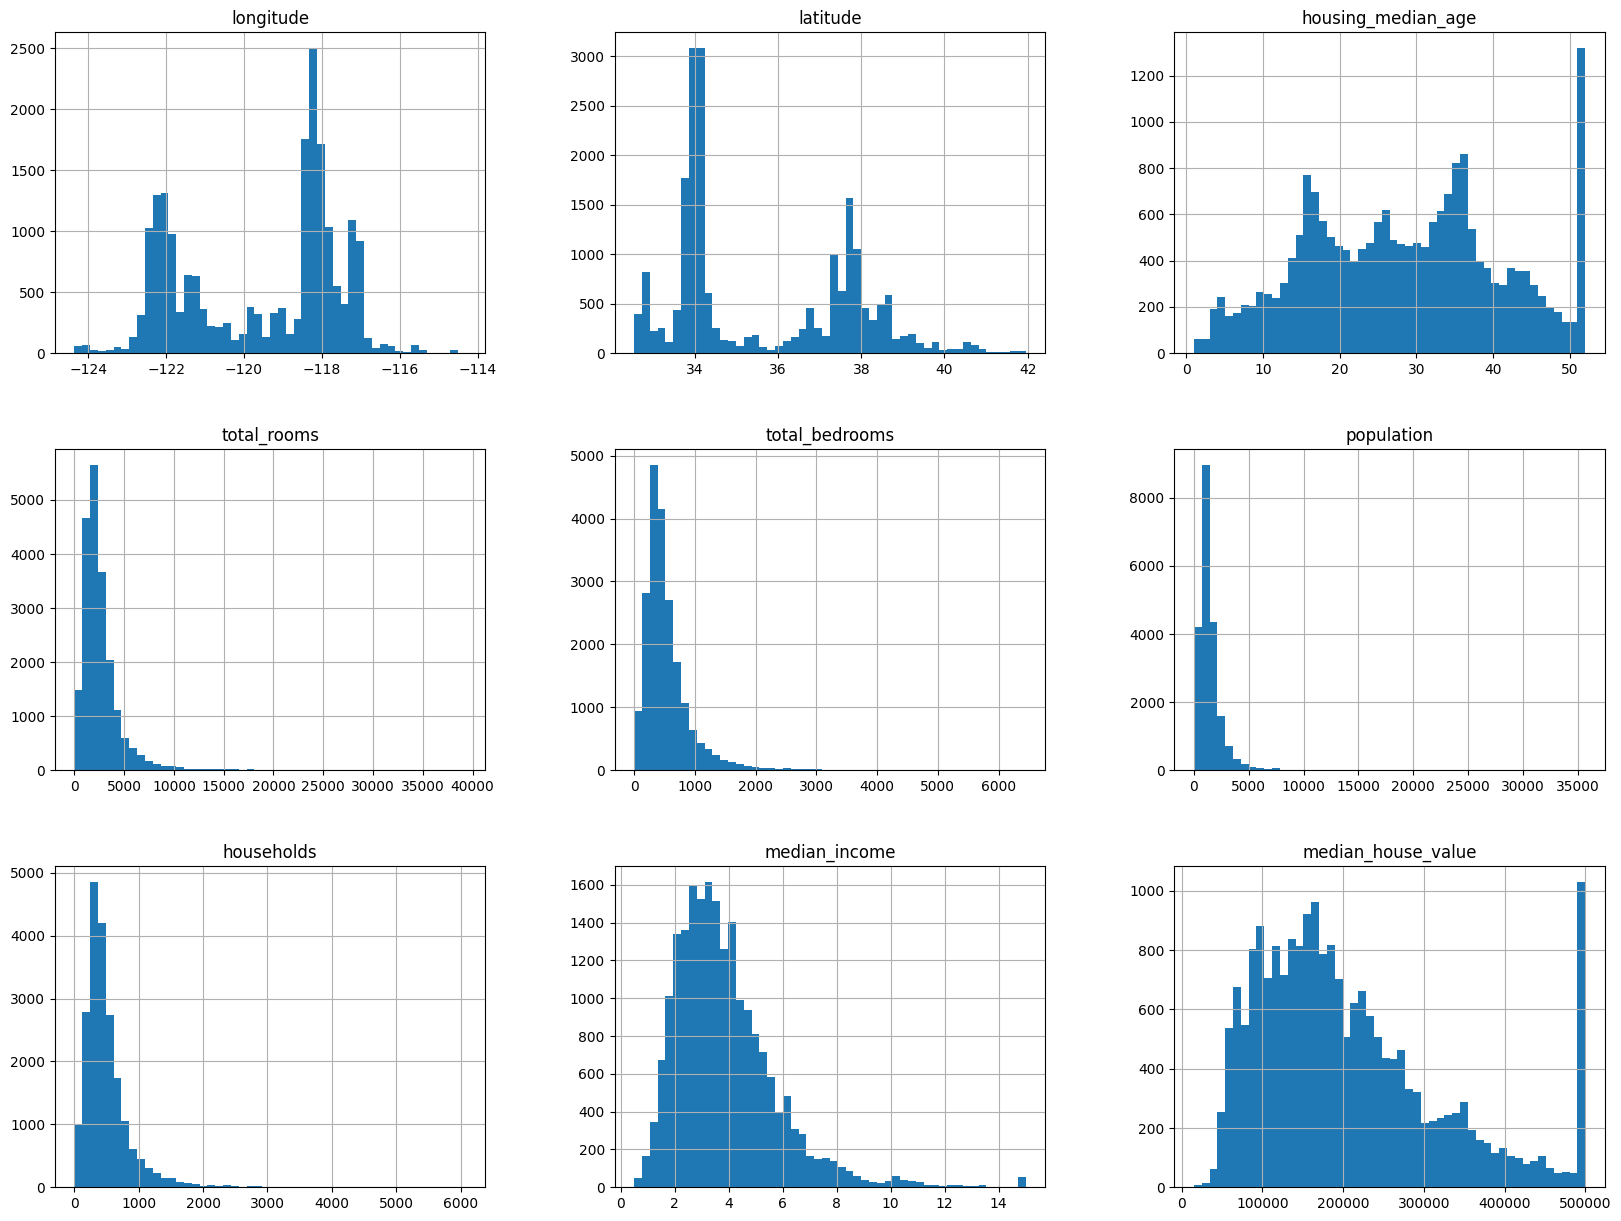

In [ ]:
housing_df.hist(bins=50, figsize=(20,15));

# plt.show()

**Observation**

*   There are outliers for "housing_median_age" & "median_house_value"
*   Because there are odd peak values as its maximum value.



---





**2. Heat Maps**

Show the correlation between features or how one feature is related to another feature.

*   **If features are highly ocrrelated** -> Those features could possible teach the model the same thing.
*   **Duplicated features should be removed** to speed up the training process, save money & improve the model prediction capability.



---


🔹 READING THE HEATMAP

*   Except the line from top left to bottom right (All take 1): Other cells expect to values FROM 0 TO 1.
*   **Value closure to 0 ** -> Shows low correlation
*   **Values closure to 1** -> Shows high correlation





*   **.corr()** -> calculates correlation
*   Correlation only works on numerical values.
*   'ocean_proximity' feature is not a numeric value'
*   So use -> corr = housing_df.corr(**numeric_only=True**)



In [ ]:
corr = housing_df.corr(numeric_only=True)

#convert output with 5 decimal points
corr.round(5)

#print(corr.round(5))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00000,-0.92466,-0.10820,0.04457,0.06888,0.09977,0.05531,-0.01518,-0.04597
latitude,-0.92466,1.00000,0.01117,-0.03610,-0.06646,-0.10878,-0.07104,-0.07981,-0.14416
housing_median_age,-0.10820,0.01117,1.00000,-0.36126,-0.32118,-0.29624,-0.30292,-0.11903,0.10562
total_rooms,0.04457,-0.03610,-0.36126,1.00000,0.93046,0.85713,0.91848,0.19805,0.13415
total_bedrooms,0.06888,-0.06646,-0.32118,0.93046,1.00000,0.87774,0.97868,-0.00704,0.05025
population,0.09977,-0.10878,-0.29624,0.85713,0.87774,1.00000,0.90722,0.00483,-0.02465
households,0.05531,-0.07104,-0.30292,0.91848,0.97868,0.90722,1.00000,0.01303,0.06584
median_income,-0.01518,-0.07981,-0.11903,0.19805,-0.00704,0.00483,0.01303,1.00000,0.68808
median_house_value,-0.04597,-0.14416,0.10562,0.13415,0.05025,-0.02465,0.06584,0.68808,1.00000


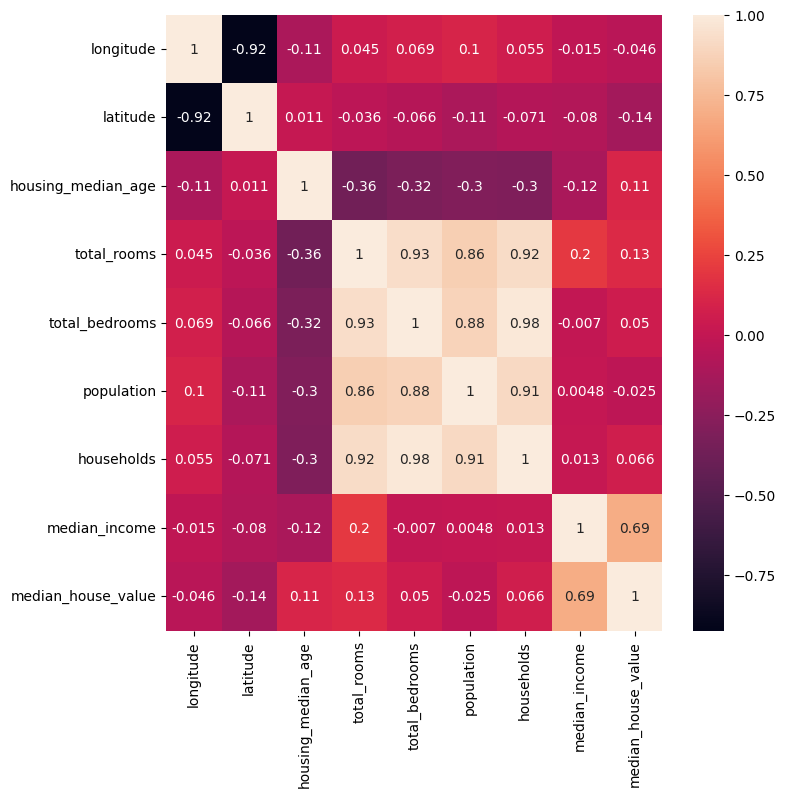

In [ ]:
#Make a heatmap larger in size.

plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True);



*   If light pink appears more than once in a row; consider those features are correlted.

> **Example:** total_rooms, total_bedrooms, population and households are highly correlated features. So they are candidates for removal.



# Feature Engineering

---

**A process of manipulating data by;**
*   Adding new features
*   Removing highly correlated or duplicated features
*   Combining features (highly correlated features)
*   Creating new features



🔹For feature engineering requires fully understanding of the data and the relationship between features.

In [ ]:
# Above scenario we already identify total_rooms, total_bedrooms, population and households are highly correlated features.
# Strategy - Create a relatively simple combination of the correlated features and drop the rest.

# 1. A new feature -> rooms_per_household.
housing_df['rooms_per_household'] = housing_df['total_rooms']/housing_df['households']

# 2. A new feature -> bedrooms_per_room.
housing_df['bedrooms_per_room'] = housing_df['total_bedrooms']/housing_df['total_rooms']

# 3. A new feature -> population_per_household.
housing_df['population_per_household'] = housing_df['population']/ housing_df['households']

# Create a new feature by combining the longitude and latitude (because there's a negative correlation)
housing_df['coords'] = housing_df['longitude']+housing_df['latitude']

housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [ ]:
# After created the above new fetures, then remove the original correlated features

housing_df = housing_df.drop(['total_rooms','total_bedrooms','population','households','longitude','latitude'], axis = 1)

# Also can seperately delete each feature like -> housing_df = housing_df.drop('total_rooms', axis = 1)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   rooms_per_household       20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


**New heat map after removing correlation**

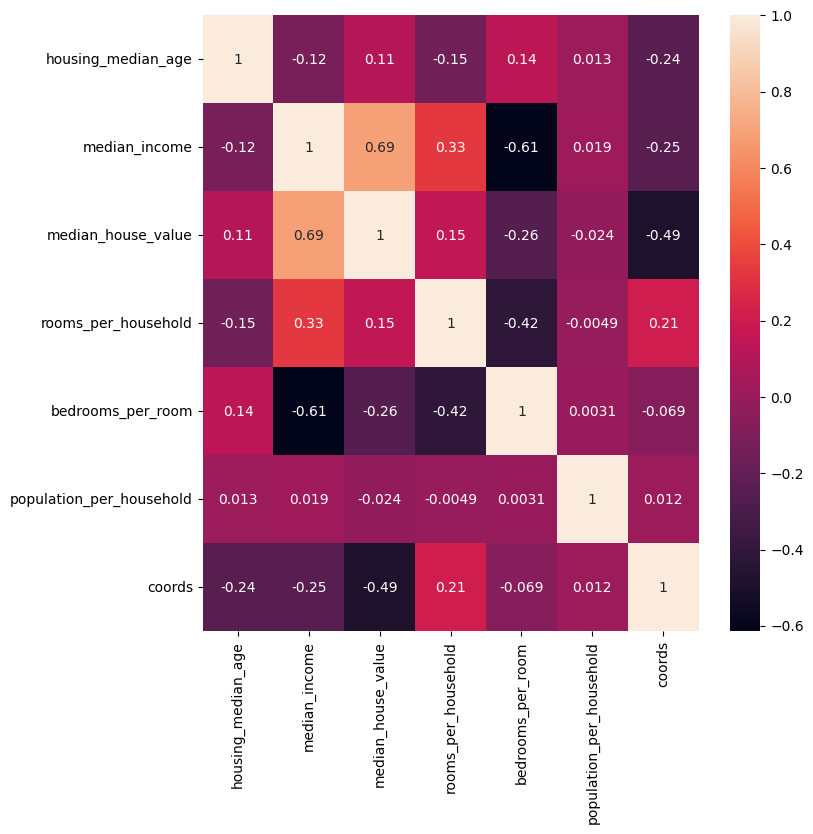

In [ ]:
corr = housing_df.corr(numeric_only=True)

#convert output with 5 decimal points
corr.round(5)

#make the heatmap larger in size
plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True)
plt.show()

🔹 In this new heat map, high correlations no longer exsist.

**Encode Categorical Data**

Most ML algorithms learn from numeric data. Therefore categorical data must be encoded. (or convert into numeric data.)


🔹 Encoding Technique Used - **One Hot Encoding**

🔹 After encoding can remove the original columns (features)

🔹 One-hot encoding can cause *HIGH CARDINALITY* -> means increased features results in dimentionality

> (This is not good since when # of features increase it's harder to models to learn, reduce generalize and increased training cost.)



In [ ]:
# see unique categories for OCEAN_PROXIMITY
housing_df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
# count the values of each OCEAN_PROXIMITY category
housing_df.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
# One Hot Encoding

# Use panda's get_dummies() function

ocean_encoded = pd.get_dummies(housing_df['ocean_proximity'], dtype=int)
ocean_encoded

# can write this in sigle line -> print(pd.get_dummies(housing_df['ocean_proximity'])) ; output get in TRUE/False format


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
20635,0,1,0,0,0
20636,0,1,0,0,0
20637,0,1,0,0,0
20638,0,1,0,0,0


In [ ]:
# Replace 'ocean_proximity' column in the dataset using get_dummies() function
housing_df_encoded = pd.get_dummies(housing_df, columns = ['ocean_proximity'], dtype=int)


# print the first few observations
# NOTE: ocean_proximity column is gone now.

housing_df_encoded.head()


,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,-84.35,0,0,0,1,0
1,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,-84.36,0,0,0,1,0
2,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,-84.39,0,0,0,1,0
3,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,-84.40,0,0,0,1,0
4,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,-84.40,0,0,0,1,0


In [ ]:
housing_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   housing_median_age          20640 non-null  float64
 1   median_income               20640 non-null  float64
 2   median_house_value          20640 non-null  float64
 3   rooms_per_household         20640 non-null  float64
 4   bedrooms_per_room           20640 non-null  float64
 5   population_per_household    20640 non-null  float64
 6   coords                      20640 non-null  float64
 7   ocean_proximity_<1H OCEAN   20640 non-null  int64  
 8   ocean_proximity_INLAND      20640 non-null  int64  
 9   ocean_proximity_ISLAND      20640 non-null  int64  
 10  ocean_proximity_NEAR BAY    20640 non-null  int64  
 11  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(7), int64(5)
memory usage: 1.9 MB


# Train the model



---

Use 3 Algorithms
1.   Linear Regression Algorithm (scikit learn ML freamework with easy-to -use ML libraries )
2.   Random Forest Regression Algorithm
3.   XGBoost Algorithm




# Split the Dataset into Training and Testing


In [ ]:
# import the function
from sklearn.model_selection import train_test_split

# Define input feature (X) and target variable (y)
X = housing_df_encoded.drop('median_house_value', axis = 1)
y = housing_df_encoded['median_house_value']


# Split the dataset using numpy arrays
# X-> array with inputs; y-> Array with outputs

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.3)

# Confirm how the data was split
print(X_train.shape)
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 11)
(14448, 11)
(14448,)
(6192,)


# 01. Linear Regression - Model Training

In [ ]:
# import LinearRegression library from scikit-learning to train the model.
from sklearn.linear_model import LinearRegression

# Create a linear regressor (learning model) using all the feature variables and sotred in "reg_model".
reg_model = LinearRegression()

# Train the model using training dataset
reg_model.fit(X_train, y_train)

LinearRegression()

**✅ Run the Predictions** (Once the Training Process is Completed)



In [ ]:
# Run the predictions on training and testing data
y_pred_train = reg_model.predict(X_train)

y_pred_test = reg_model.predict(X_test)

**✅ Evaluate the model**

In [ ]:
# Compare the actual value and the values predicted by the model
pred_test_df = pd.DataFrame({'Actual':y_test, 'Predicted': y_pred_test})

print(pred_test_df)

         Actual      Predicted
20046   47700.0   68349.200353
3024    45800.0  129589.631971
15663  500001.0  248852.441665
20484  218600.0  296553.001376
9814   278000.0  239761.580018
...         ...            ...
17505  237500.0  213523.039410
13512   67300.0   80405.507129
10842  218400.0  214937.968070
16559  119400.0  137178.532117
5786   209800.0  196909.252997

[6192 rows x 2 columns]


**Ecaluate the model using R-Squard Metric**

R-squared gives the diffference between actual and the predictive values

🔹 Returns 1 -> The model is perfect ; 0 -> The model will perform poorly on unseen data



In [ ]:
r2_reg_model_test = round(reg_model.score(X_test, y_test)*100,2)

print('R^2: {}%'.format(r2_reg_model_test))


R^2: 61.68%


# 02. Random Forest Algorithm - Model Training

In [ ]:
# import the necessary libraries
# import RandomForestRegressor library from scikit-learning to train the model.
from sklearn.ensemble import RandomForestRegressor

# Create a  regressor (learning model) using all the feature variables and sotred in "rf_model".
rf_model = RandomForestRegressor(n_estimators=50, random_state=10)

# Train the model using training dataset
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=10)

**✅ Run the Predictions** (Once the Training Process is Completed)



In [ ]:
# Run the predictions on training and testing data
y_rf_pred_train = rf_model.predict(X_train)

y_rf_pred_test = rf_model.predict(X_test)

**✅ Evaluate the model**

In [ ]:
# Compare the actual value (target) with the values predicted by the model
rf_pred_test_df = pd.DataFrame({'Actual':y_test, 'Predicted': y_rf_pred_test})

print(rf_pred_test_df)

         Actual  Predicted
20046   47700.0   57140.00
3024    45800.0   97988.00
15663  500001.0  427834.36
20484  218600.0  258796.00
9814   278000.0  296668.06
...         ...        ...
17505  237500.0  247292.02
13512   67300.0   65656.00
10842  218400.0  205192.00
16559  119400.0  130238.00
5786   209800.0  217860.00

[6192 rows x 2 columns]


In [ ]:
# Evaluate the model performance using R-Squared metric

from sklearn.metrics import r2_score

score = r2_score(y_test, y_rf_pred_test)

score_percent = round(score*100,2)
print('R^2: {}%'.format(score_percent))

R^2: 78.65%


**Observations**

Random forest is better than the linear regression with no major changes in the dataset

In [ ]:
# Determine Mean Square Error (MSE) and Root Mean Square Error (RMSE)

from sklearn.metrics import mean_squared_error
import math

mse = mean_squared_error(y_test, y_rf_pred_test)
rmse = math.sqrt(mse)

print('MSE = ', mse)
print('RMSE = ', rmse)

MSE =  2802679051.3548317
RMSE =  52940.33482473294


In [ ]:
# Calculate Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_rf_pred_test)

print('MAE = ', mae)

MAE =  35805.27072351421


**Observations**

RMSE is larger than MAE value; this means there's a large errors in the dataset

# Determine Feature Importance

Random forest algorithm is that it gives you the ‘feature importance’ for all the variables in the data.



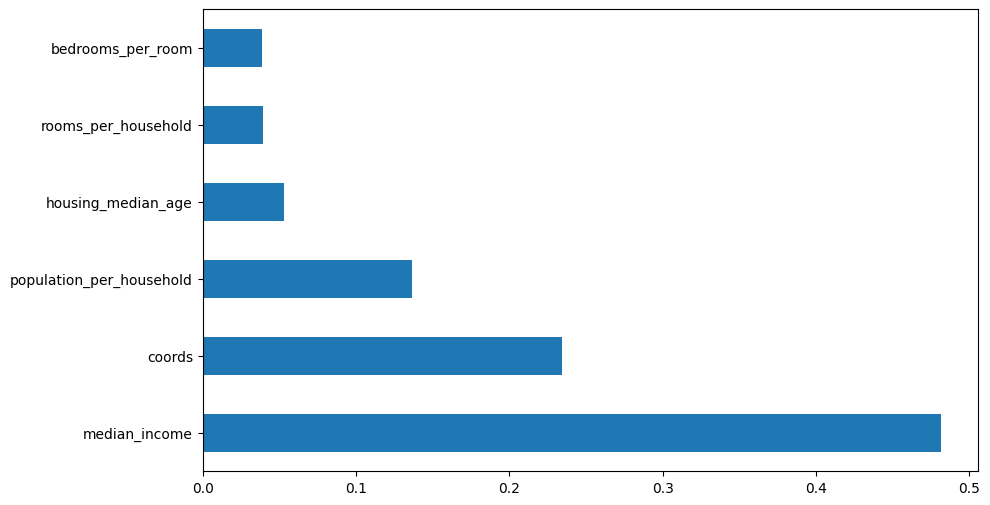

In [ ]:
#Plot 6 most important features
plt.figure(figsize=(10,6))
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.nlargest(6).plot(kind='barh');

**Now we can train the random forest model using these 6 fetures only & observe the changes in RMSE values for the train and the validation set.**

In [ ]:
# Train the dataset with the 6 most important features
train_x_if = X_train[['bedrooms_per_room',
                      'housing_median_age',
                      'coords',
                      'rooms_per_household',
                      'population_per_household',
                      'median_income']]
test_x_if = X_test[['bedrooms_per_room',
                      'housing_median_age',
                      'coords',
                      'rooms_per_household',
                      'population_per_household',
                      'median_income']]


# Create an object of the Random Forest Regression Model
rf_model_if = RandomForestRegressor(n_estimators=50, random_state=10)

# Fit the model with the training data
rf_model_if.fit(train_x_if, y_train)






RandomForestRegressor(n_estimators=50, random_state=10)

In [ ]:
# Predict the target on the test data
predict_test_with_if = rf_model_if.predict(test_x_if)

In [ ]:
# Determine Root Mean Square Error (RMSE)

from sklearn.metrics import mean_squared_error
import math

mse = mean_squared_error(y_test, predict_test_with_if )
rmse = math.sqrt(mse)

print('RMSE = ', rmse)

RMSE =  54855.78063874143


**Observation**

Here we can see using the 6 features gives the similar performance as using all of the features.

# 03. XGBoost Algorithm - Model Training

In [ ]:
# XGBoost is an open source library. It provides an efficient and effective implementation of the XGBoost algorithm.
# use the scikit-learn wrapper classes: XGBRegresssor and XGBClassifier

from xgboost import XGBRegressor

# Create a XGB Regressor (learning model) and sotred in "xgb_model".
xgb_model = XGBRegressor()

# Clean column names for XGBoost compatibility
# Replace problematic characters like <, [, ] with an empty string
X_train.columns = X_train.columns.str.replace(r'[\<\>\[\]]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\<\>\[\]]', '', regex=True)
# Replace spaces with underscores (if any)
X_train.columns = X_train.columns.str.replace(' ', '_', regex=False)
X_test.columns = X_test.columns.str.replace(' ', '_', regex=False)

# Train the model using training dataset.
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

**✅ Run the Predictions** (Once the Training Process is Completed)



In [ ]:
# Run the predictions on training and testing data
y_xgb_pred_train = xgb_model.predict(X_train)

y_xgb_pred_test = xgb_model.predict(X_test)

**✅ Evaluate the model**

In [ ]:
# Compare the actual value (target) with the values predicted by the model
xgb_pred_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_xgb_pred_test})

print(xgb_pred_test_df)

         Actual      Predicted
20046   47700.0   54832.507812
3024    45800.0   68960.929688
15663  500001.0  469467.781250
20484  218600.0  251928.234375
9814   278000.0  298786.500000
...         ...            ...
17505  237500.0  245610.765625
13512   67300.0   61382.644531
10842  218400.0  229526.812500
16559  119400.0  122367.992188
5786   209800.0  195862.265625

[6192 rows x 2 columns]


In [ ]:
# Evaluate the model performance using R-Squared metric

score = r2_score(y_test, y_xgb_pred_test)

score_percent = round(score*100,2)
print('R^2: {}%'.format(score_percent))

# r2_xgb_model_test = round(xgb_model.score(X_test, y_test),2)
# print("R^2 Test: {}".format(r2_xgb_model_test))

R^2: 78.14%


In [ ]:
# Evaluate the model performance using Mean Squared Error(MSE) and Root Mean Squared Error(RMSE)

from sklearn.metrics import mean_squared_error
import math

mse = mean_squared_error(y_test, y_xgb_pred_test)
rmse = math.sqrt(mse)

print('MSE = ', mse)
print('RMSE = ', rmse)

MSE =  2869699058.3178105
RMSE =  53569.57213118106


In [ ]:
# Calculate Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_xgb_pred_test)

print('MAE = ', mae)

MAE =  36703.01767716913


In [ ]:
#Determine hyperparameters availble for learning algorithms (Here for XGBoost algorithm)

xgb_model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

**Common Hyperparameters in XGBoost**

1.   n_estimators - number of trees (default value - 100)
2.   max_depth - maximum depth of each tree (often between 1 - 10 | default value - 6)
3.   learning_rate - weight each model
4.   subsample - number of samples or observations used in each tree. (set value between 0 & 1 | often use 1)
5.   colsample_bytree - number of features/columns used by each tree. (set value between 0 & 1 | often use 1)
6.   List item






**Hyperparameter Tuning 01**



In [ ]:
xgb_model_2 = XGBRegressor(
    gamma=0.05,
    learning_rate=0.01,
    max_depth=6,
    n_estimators=1000,
    n_jobs=16,
    objective='reg:squarederror',
    subsample=0.8,
    scale_pos_weight=0,
    reg_alpha=0,
    reg_lambda=1,
    verbosity=1
)

# model training
xgb_model_2.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=16, num_parallel_tree=None, ...)

In [ ]:
# Run the predictions on training and testing data
y_xgb_2_pred_train = xgb_model_2.predict(X_train)

y_xgb_2_pred_test = xgb_model_2.predict(X_test)

In [ ]:
# compare the actual values with predictive values
xgb_2_pred_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_xgb_2_pred_test})

print(xgb_2_pred_test_df)

         Actual      Predicted
20046   47700.0   59567.097656
3024    45800.0  107459.132812
15663  500001.0  464661.500000
20484  218600.0  244704.656250
9814   278000.0  280180.375000
...         ...            ...
17505  237500.0  259423.468750
13512   67300.0   63445.925781
10842  218400.0  218530.625000
16559  119400.0  119920.046875
5786   209800.0  191160.062500

[6192 rows x 2 columns]


In [ ]:
# Evaluate the model performance using R-Squared metric

score_2 = r2_score(y_test, y_xgb_2_pred_test)

score_percent = round(score_2*100,2)
print('R^2: {}%'.format(score_percent))


#r2_xgb_model_2_test = round(xgb_model_2.score(X_test, y_test),2)
#print("R^2 Test: {}".format(r2_xgb_model_2_test))

R^2: 79.77%


**Hyperparameter Tuning 02**



In [ ]:
xgb_model_3 = XGBRegressor(
    gamma=0.09,
    colsample_bytree = 1,
    learning_rate=0.01,
    max_depth=8,
    n_estimators=1100,
    n_jobs=30,
    objective='reg:squarederror',
    subsample=0.8,
    scale_pos_weight=0,
    reg_alpha=0,
    reg_lambda=1,
    verbosity=1
)

# model training
xgb_model_3.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.09, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1100, n_jobs=30,
             num_parallel_tree=None, ...)

In [ ]:
# Run the predictions on training and testing data
y_xgb_3_pred_train = xgb_model_3.predict(X_train)

y_xgb_3_pred_test = xgb_model_3.predict(X_test)

In [ ]:
# compare the actual values with predictive values
xgb_3_pred_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_xgb_3_pred_test})

print(xgb_3_pred_test_df)

         Actual      Predicted
20046   47700.0   57364.089844
3024    45800.0   73012.312500
15663  500001.0  481819.156250
20484  218600.0  253811.562500
9814   278000.0  281674.437500
...         ...            ...
17505  237500.0  246461.625000
13512   67300.0   60491.710938
10842  218400.0  214193.437500
16559  119400.0  122381.898438
5786   209800.0  201332.750000

[6192 rows x 2 columns]


In [ ]:
# Evaluate the model performance using R-Squared metric

score_3 = r2_score(y_test, y_xgb_3_pred_test)

score_percent = round(score_3*100,2)
print('R^2: {}%'.format(score_percent))


#r2_xgb_model_3_test = round(xgb_model_3.score(X_test, y_test),2)
#print("R^2 Test: {}".format(r2_xgb_model_3_test))

R^2: 80.13%
